# Data Cleaning, EDA & EAD reconstruction

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make src/ importable
sys.path.append("../src")

from cleaning import clean_loan_tape
from amortization import add_ead_columns


# ---------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------

SEED = 42
np.random.seed(SEED)


# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------

INPUT_FILE = "../generated/loan_tape.csv"

CLEAN_FILE = "../outputs/cleaned/loan_tape_clean.csv"
QUALITY_FILE = "../outputs/tables/data_quality_log.csv"

Path("../outputs/cleaned").mkdir(
    parents=True,
    exist_ok=True
)

Path("../outputs/tables").mkdir(
    parents=True,
    exist_ok=True
)

### 1. Load Data

In [2]:
df_raw = pd.read_csv(INPUT_FILE)

print(f"Raw observations: {len(df_raw):,}")
print(f"Raw columns: {df_raw.shape[1]}")

display(df_raw.head())

Raw observations: 308,222
Raw columns: 12


,origination_date,loan_id,region,fico_score,term,maturity_date,default_date,prepayment_date,obs_end_date,issue_amount,amortization_type,interest_rate
0,1993-03-01,ID_00000002,Northeast,811,60,1998-03-01,1992-06-27,1996-09-15,2026-06-16,5270.56,Bullet,0.0591
1,1993-03-01,ID_00000059,Northeast,696,60,1998-03-01,1993-11-01,NaN,2026-06-16,8058.00,Italian,0.0983
2,1993-03-01,ID_00000064,Northeast,840,60,1998-03-01,1998-02-01,NaN,2026-06-16,6960.84,Bullet,0.0611
3,1993-03-01,ID_00000086,Northeast,733,12,1994-03-01,1993-08-01,NaN,2026-06-16,3071.63,Italian,0.0522
4,1993-03-01,ID_00000088,Northeast,825,60,31/02/1990,1997-06-01,1992-01-30,2026-06-16,8197.42,Bullet,0.0516


In [3]:

# Look at the gap in log-space — genuine loan sizes and data-entry errors
# should show up as two separated clusters, not a smooth tail.
amounts = df_raw.loc[df_raw["issue_amount"] > 0, "issue_amount"].sort_values().unique()
log_amounts = np.log10(amounts)

gaps = np.diff(log_amounts)
biggest_gap_idx = np.argmax(gaps)

print(f"Largest gap in log10(issue_amount) sits between:")
print(f"  €{amounts[biggest_gap_idx]:,.0f}  and  €{amounts[biggest_gap_idx + 1]:,.0f}")
print(f"  (gap size: {gaps[biggest_gap_idx]:.2f} log10 units)")

# Sanity check against the bulk of the distribution
print(f"\n95th percentile: €{np.percentile(amounts, 95):,.0f}")
print(f"99th percentile: €{np.percentile(amounts, 99):,.0f}")
print(f"99.5th percentile: €{np.percentile(amounts, 99.5):,.0f}")

Largest gap in log10(issue_amount) sits between:
  €12,560  and  €5,006,130
  (gap size: 2.60 log10 units)

95th percentile: €12,117
99th percentile: €11,271,463
99.5th percentile: €31,239,452


Some loan amounts in the dataset are clearly too large to be realistic. The sudden jump from about €12,560 to €5 million suggests a data-entry error rather than genuine loans. We therefore treat these extreme values as errors and limit them to a reasonable maximum.

In [4]:
# check how many loans are above the break
n_affected = (df_raw["issue_amount"] > 12_560).sum()
pct_affected = n_affected / len(df_raw) * 100

print(f"Loans above the break: {n_affected:,} ({pct_affected:.2f}% of raw tape)")

# Confirm there's really nothing in between (not a smooth tail you're
# arbitrarily cutting through)
between = df_raw[
    (df_raw["issue_amount"] > 12_560) & (df_raw["issue_amount"] < 5_006_130)
]
print(f"Loans strictly between the two clusters: {len(between)}") 

Loans above the break: 3,082 (1.00% of raw tape)
Loans strictly between the two clusters: 0


### 2. Initial data audit

In [5]:
df = df_raw.copy()

#print("\nColumn names:")
#print(df.columns.tolist())

print("\nData types:")
df.info()

print("\nSummary statistics:")
display(df.describe(include="all").T)


#  Parse dates
date_columns = [
        "origination_date",
        "maturity_date",
        "default_date",
        "prepayment_date",
        "obs_end_date",
    ]

for col in date_columns:
        df[col] = pd.to_datetime(
            df[col],
            errors="coerce"
        )


Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308222 entries, 0 to 308221
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   origination_date   302144 non-null  object 
 1   loan_id            308222 non-null  object 
 2   region             308222 non-null  object 
 3   fico_score         308222 non-null  int64  
 4   term               308222 non-null  int64  
 5   maturity_date      302147 non-null  object 
 6   default_date       41611 non-null   object 
 7   prepayment_date    38004 non-null   object 
 8   obs_end_date       308222 non-null  object 
 9   issue_amount       308222 non-null  float64
 10  amortization_type  307014 non-null  object 
 11  interest_rate      305173 non-null  float64
dtypes: float64(2), int64(2), object(8)
memory usage: 28.2+ MB

Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
origination_date,302144,405,1990/13/40,973,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_id,308222,302058,ID_00292078,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,308222,16,Pacific,77651,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fico_score,308222.0,NaN,NaN,NaN,573.377225,167.798945,-50.0,434.0,574.0,715.0,999.0
term,308222.0,NaN,NaN,NaN,46.207458,107.622641,-12.0,12.0,36.0,60.0,1200.0
maturity_date,302147,453,0000-00-00,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default_date,41611,8098,2008-10-01,108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prepayment_date,38004,9072,2004-04-01,86,NaN,NaN,NaN,NaN,NaN,NaN,NaN
obs_end_date,308222,1,2026-06-16,308222,NaN,NaN,NaN,NaN,NaN,NaN,NaN
issue_amount,308222.0,NaN,NaN,NaN,286576.150182,3074722.902294,-4997.0,3730.3825,6712.025,9691.0575,49994034.0


### 3. Duplicate loan IDs

In [6]:
duplicate_ids = df["loan_id"].duplicated().sum()

print(f"Total loans: {len(df):,}")
print(f"Duplicate loan IDs: {duplicate_ids:,}")

print("\nActual duplicates:")
duplicate_loans = df[df["loan_id"].duplicated(keep=False)].sort_values("loan_id")

display(duplicate_loans.tail())

Total loans: 308,222
Duplicate loan IDs: 6,164

Actual duplicates:


,origination_date,loan_id,region,fico_score,term,maturity_date,default_date,prepayment_date,obs_end_date,issue_amount,amortization_type,interest_rate
167955,2009-08-01,ID_00319775,Southwest,669,36,2012-08-01,2008-12-19,2011-08-01,2026-06-16,7392.98,Italian,0.0584
308066,2026-05-01,ID_00319844,Pacific,566,12,2027-05-01,NaT,NaT,2026-06-16,7916.86,French,0.0489
115072,1998-11-01,ID_00319844,Southeast,519,60,2003-11-01,2001-09-01,NaT,2026-06-16,-3424.00,French,0.1166
268739,1993-08-01,ID_00319910,Pacific,507,12,1994-08-01,NaT,NaT,2026-06-16,0.00,Bullet,0.1087
308132,2026-06-01,ID_00319910,Pacific,441,12,2027-06-01,2028-05-31,NaT,2026-06-16,10414.94,French,0.0599


### 4. Missing-value audit

In [7]:
dq_missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "dtype": df.dtypes.astype(str)
})

dq_missing = dq_missing.sort_values("missing_count", ascending=False)

display(dq_missing)

,missing_count,missing_pct,dtype
prepayment_date,270218,87.669926,datetime64[ns]
default_date,266611,86.499666,datetime64[ns]
origination_date,10701,3.471848,datetime64[ns]
maturity_date,10698,3.470875,datetime64[ns]
interest_rate,3049,0.989222,float64
amortization_type,1208,0.391925,object
loan_id,0,0.000000,object
region,0,0.000000,object
fico_score,0,0.000000,int64
term,0,0.000000,int64


### 5. Impossible dates

In [8]:
def date_integrity_checks(df):

    checks = {
        "default_before_origination":
            (
                df["default_date"].notna()
                &
                (
                    df["default_date"]
                    <
                    df["origination_date"]
                )
            ).sum(),

        "prepayment_before_origination":
            (
                df["prepayment_date"].notna()
                &
                (
                    df["prepayment_date"]
                    <
                    df["origination_date"]
                )
            ).sum(),

        "obs_before_origination":
            (
                df["obs_end_date"]
                <
                df["origination_date"]
            ).sum()
    }

    return pd.Series(checks)

display(date_integrity_checks(df))

default_before_origination       5836
prepayment_before_origination    4286
obs_before_origination              0
dtype: int64

### 6. Numeric checks

In [9]:
def numeric_integrity_checks(df):

    return pd.DataFrame({
        "issue":[
            "invalid_fico",
            "invalid_rate",
            "invalid_term",
            "invalid_amount"
        ],

        "count":[
            ((df["fico_score"]<300)|(df["fico_score"]>850)).sum(),

            ((df["interest_rate"]<=0)|(df["interest_rate"]>1)).sum(),

            ((df["term"]<=0)|(df["term"]>120)).sum(),

            (df["issue_amount"]<=0).sum()
        ]
    })
    
display(numeric_integrity_checks(df))

,issue,count
0,invalid_fico,6164
1,invalid_rate,3483
2,invalid_term,6164
3,invalid_amount,6108


### 7. Region audit

In [10]:
# we first inspect the raw categories to see if there are any obvious issues
print("Raw region categories:")
print(df["region"].value_counts(dropna=False).sort_index())

Raw region categories:
region
  Northeast       643
  Pacific         739
  Southeast       799
  Southwest       797
NORTHEAST         708
Northe@st         702
Northeast       66169
P@cific           779
PACIFIC           831
Pacific         77651
SOUTHEAST         841
SOUTHWEST         805
Southe@st         809
Southeast       77551
Southwest       77605
Southwest_        793
Name: count, dtype: int64


In [11]:
valid_regions = {
    "Northeast",
    "Pacific",
    "Southeast",
    "Southwest"
}

# identify unexpected values
invalid_regions = ~df["region"].isin(valid_regions)

print(f"Non-standard region values: {invalid_regions.sum():,}")

display(
    df.loc[invalid_regions, "region"]
    .value_counts(dropna=False)
)

Non-standard region values: 9,246


region
SOUTHEAST       841
PACIFIC         831
Southe@st       809
SOUTHWEST       805
  Southeast     799
  Southwest     797
Southwest_      793
P@cific         779
  Pacific       739
NORTHEAST       708
Northe@st       702
  Northeast     643
Name: count, dtype: int64

### 8. Amortisation-type audit

In [12]:
#  Check for valid amortization types
print("Raw amortization types:")
print(
    df["amortization_type"]
    .value_counts(dropna=False)
)

# we inspect unusual values
expected_amortization = {
    "French",
    "Bullet",
    "Italian"
}

unexpected_amortization = (
    ~df["amortization_type"].isin(expected_amortization)
    & df["amortization_type"].notna()
)

print(
    f"Unexpected amortization types: "
    f"{unexpected_amortization.sum():,}"
)

display(
    df.loc[
        unexpected_amortization,
        "amortization_type"
    ].value_counts()
)

Raw amortization types:
amortization_type
Italian    100724
French     100670
Bullet     100664
ITALIAN      1272
Frnch        1235
bullet       1226
XYZ          1223
NaN          1208
Name: count, dtype: int64
Unexpected amortization types: 4,956


amortization_type
ITALIAN    1272
Frnch      1235
bullet     1226
XYZ        1223
Name: count, dtype: int64

In [13]:
missing_pct = (
    df["amortization_type"].isna().mean()
    * 100
)

print(missing_pct) # Percentage of missing values in the amortization_type column

0.39192530059502567


1,208 loans (0.39%) had missing amortization structure, making EAD reconstruction impossible. These records were removed.

### 9. Default/prepayment consistency audit

In [14]:
# loans in each event
print(
    f"Loans with default date: "
    f"{df['default_date'].notna().sum():,}"
)

print(
    f"Loans with prepayment date: "
    f"{df['prepayment_date'].notna().sum():,}"
)

# loans with both events
both_events = (
    df["default_date"].notna() &
    df["prepayment_date"].notna()
)

print(f"Loans with both events: {both_events.sum():,}")


# we determine which event occured first
default_first = (
    both_events &
    (df["default_date"] < df["prepayment_date"])
)

prepayment_first = (
    both_events &
    (df["prepayment_date"] < df["default_date"])
)

same_day = (
    both_events &
    (df["default_date"] == df["prepayment_date"])
)

event_issues = pd.DataFrame({
    "check": [
        "Default before prepayment",
        "Prepayment before default",
        "Default and prepayment same day"
    ],
    "count": [
        default_first.sum(),
        prepayment_first.sum(),
        same_day.sum()
    ]
})

display(event_issues)

Loans with default date: 41,611
Loans with prepayment date: 38,004
Loans with both events: 7,981


,check,count
0,Default before prepayment,4017
1,Prepayment before default,3962
2,Default and prepayment same day,2


In [15]:
print(f"Default date coverage: {df['default_date'].notna().mean():.2%}")
print(f"Prepayment date coverage: {df['prepayment_date'].notna().mean():.2%}")

Default date coverage: 13.50%
Prepayment date coverage: 12.33%


### 10. Maturity consistency audit

In [16]:
# Since we have a calendar-month maturity, we can compute the expected maturity directly

df["expected_maturity"] = pd.NaT

valid_maturity_inputs = (
    df["origination_date"].notna() &
    df["term"].notna()
)

df.loc[valid_maturity_inputs, "expected_maturity"] = [
    date + pd.DateOffset(months=int(term))
    for date, term in zip(
        df.loc[valid_maturity_inputs, "origination_date"],
        df.loc[valid_maturity_inputs, "term"]
    )
]

# we compare them
maturity_errors = (
    df["maturity_date"].notna() &
    df["expected_maturity"].notna() &
    (df["maturity_date"] != df["expected_maturity"])
)

print(f"Maturity inconsistencies: {maturity_errors.sum():,}")


# inspection
display(
    df.loc[
        maturity_errors,
        [
            "loan_id",
            "origination_date",
            "term",
            "maturity_date",
            "expected_maturity"
        ]
    ].head(20)
)

Maturity inconsistencies: 5,721


,loan_id,origination_date,term,maturity_date,expected_maturity
135,ID_00001525,1994-06-01,-12,1997-06-01,1993-06-01
252,ID_00002831,1995-07-01,1200,2000-07-01,2095-07-01
259,ID_00002851,1995-07-01,1200,2000-07-01,2095-07-01
303,ID_00003474,1996-01-01,-12,1999-01-01,1995-01-01
322,ID_00003680,1996-03-01,0,1999-03-01,1996-03-01
331,ID_00003961,1996-06-01,0,2001-06-01,1996-06-01
350,ID_00004131,1996-08-01,-12,1997-08-01,1995-08-01
438,ID_00005351,1997-08-01,-12,2002-08-01,1996-08-01
451,ID_00005507,1997-10-01,-12,2002-10-01,1996-10-01
581,ID_00006899,1998-11-01,1200,2003-11-01,2098-11-01


# Cleaning

In [17]:
df_clean, quality_log = clean_loan_tape(
    input_file=INPUT_FILE,
    output_file=CLEAN_FILE
)


quality_log_report = quality_log.copy()

quality_log_report["impact"] = np.where(
    quality_log_report["rule"].str.contains(
        "Remove",
        case=False,
        na=False
    ),
    "Rows removed",
    "Rows retained"
)

quality_log_report = quality_log_report.rename(
    columns={
        "defect": "Defect",
        "count": "Affected Loans",
        "rule": "Treatment Rule",
        "pct_original_rows": "% of Raw Tape"
    }
)

display(
    quality_log_report.style.format({
        "% of Raw Tape": "{:.2f}%"
    })
)

#save
quality_log_report.to_csv(
    QUALITY_FILE,
    index=False
)

#print("\nColumn names:")
display(df_clean.columns.tolist())

df_clean.shape, df_clean.head()

,Defect,Affected Loans,Treatment Rule,% of Raw Tape,impact
0,Duplicate loan_id,6164,Keep first occurrence and remove subsequent duplicates,2.00%,Rows removed
1,Invalid/unrecognised region,0,Set to missing; investigate before modelling,0.00%,Rows retained
2,Invalid amortization type (XYZ),1202,Remove because EAD cannot be reconstructed,0.39%,Rows removed
3,Missing amortization type,1191,Remove because EAD cannot be reconstructed,0.39%,Rows removed
4,Other unrecognised amortization types,2393,Remove because EAD cannot be reconstructed,0.78%,Rows removed
5,Invalid FICO score,6028,Set FICO to missing and retain loan,1.96%,Rows retained
6,Invalid interest rate,3419,Set interest rate to missing and flag,1.11%,Rows retained
7,Non-positive term,3048,Remove because contractual maturity cannot be determined,0.99%,Rows removed
8,Term above 120 months,2987,Remove because it is outside the documented contractual range,0.97%,Rows removed
9,Non-positive issue amount,5990,Remove because exposure cannot be defined,1.94%,Rows removed


['origination_date',
 'loan_id',
 'region',
 'fico_score',
 'term',
 'maturity_date',
 'default_date',
 'prepayment_date',
 'obs_end_date',
 'issue_amount',
 'amortization_type',
 'interest_rate',
 'region_original',
 'amortization_original',
 'fico_invalid_flag',
 'interest_rate_invalid_flag',
 'term_invalid_flag',
 'issue_amount_invalid_flag',
 'issue_amount_original',
 'issue_amount_extreme_flag',
 'default_date_invalid_flag',
 'prepayment_date_invalid_flag',
 'default_after_obs_flag',
 'prepayment_after_obs_flag',
 'competing_event_flag',
 'same_day_event_flag',
 'maturity_original',
 'expected_maturity',
 'default_event',
 'prepayment_event',
 'event_date',
 'event_type',
 'censoring_date',
 'analysis_end_date',
 'loan_age_days',
 'loan_age_months']

((277867, 36),
   origination_date      loan_id     region  fico_score  term maturity_date  \
 0       1993-03-01  ID_00000002  Northeast       811.0    60    1998-03-01   
 1       1993-03-01  ID_00000059  Northeast       696.0    60    1998-03-01   
 2       1993-03-01  ID_00000064  Northeast       840.0    60    1998-03-01   
 3       1993-03-01  ID_00000086  Northeast       733.0    12    1994-03-01   
 4       1993-03-01  ID_00000088  Northeast       825.0    60    1998-03-01   
 
   default_date prepayment_date obs_end_date  issue_amount  ...  \
 0          NaT      1996-09-15   2026-06-16       5270.56  ...   
 1   1993-11-01             NaT   2026-06-16       8058.00  ...   
 2   1998-02-01             NaT   2026-06-16       6960.84  ...   
 3   1993-08-01             NaT   2026-06-16       3071.63  ...   
 4   1997-06-01             NaT   2026-06-16       8197.42  ...   
 
   maturity_original  expected_maturity default_event prepayment_event  \
 0        1998-03-01         19

# Compute EAD

In [18]:
print("Computing outstanding loan balances and EAD values.")

df_clean = add_ead_columns(df_clean)


# Save the updated dataframe
df_clean.to_csv(CLEAN_FILE, index=False)

print("Updated clean dataset saved successfully.")

Computing outstanding loan balances and EAD values.


Updated clean dataset saved successfully.


# Post-Cleaning Validation

In [19]:
validation_checks = pd.Series({

    "Default before origination":
        (
            df_clean["default_date"].notna()
            &
            (df_clean["default_date"] < df_clean["origination_date"])
        ).sum(),

    "Prepayment before origination":
        (
            df_clean["prepayment_date"].notna()
            &
            (df_clean["prepayment_date"] < df_clean["origination_date"])
        ).sum(),

    "Default after observation date":
        (
            df_clean["default_date"].notna()
            &
            (df_clean["default_date"] > df_clean["obs_end_date"])
        ).sum(),

    "Prepayment after observation date":
        (
            df_clean["prepayment_date"].notna()
            &
            (df_clean["prepayment_date"] > df_clean["obs_end_date"])
        ).sum(),

    "Negative EAD":
        (df_clean["EAD_at_default"] < 0).sum(),

    "EAD > issue amount":
        (
            df_clean["EAD_at_default"]
            > df_clean["issue_amount"]
        ).sum(),

    "Negative balance":
        (
            df_clean["balance_at_obs_end"] < 0
        ).sum(),

    "Balance > issue amount":
        (
            df_clean["balance_at_obs_end"]
            > df_clean["issue_amount"]
        ).sum()
})

display(validation_checks.to_frame("Count"))

,Count
Default before origination,0
Prepayment before origination,0
Default after observation date,0
Prepayment after observation date,0
Negative EAD,0
EAD > issue amount,0
Negative balance,0
Balance > issue amount,0


# EDA

### 1. Missing values 

In [20]:
print("=" * 80)
print("MISSING VALUE ANALYSIS")
print("=" * 80)
print("The table below shows all remaining missing values after cleaning.")
print()

missing_summary = pd.DataFrame({
    "Missing Count": df_clean.isna().sum(),
    "Missing %": (
        df_clean.isna().mean() * 100
    ).round(2)
})

display(
    missing_summary[
        missing_summary["Missing Count"] > 0
    ].sort_values(
        "Missing Count",
        ascending=False
    )
)


MISSING VALUE ANALYSIS
The table below shows all remaining missing values after cleaning.



,Missing Count,Missing %
balance_at_prepayment,251188,90.40
prepayment_date,250620,90.19
EAD_at_default,249975,89.96
default_date,249391,89.75
event_date,222144,79.95
maturity_original,9647,3.47
interest_rate,5886,2.12
balance_at_obs_end,5886,2.12
fico_score,5542,1.99


### 2. Variable validation

In [21]:
print("\n" + "=" * 80)
print("FICO SCORE DISTRIBUTION")
print("=" * 80)
print("Summary statistics for borrower credit quality.")
display(df_clean["fico_score"].describe())

print("\n" + "=" * 80)
print("LOAN TERM DISTRIBUTION")
print("=" * 80)
print("Summary statistics for loan maturity.")
display(df_clean["term"].describe())

print("\n" + "=" * 80)
print("ISSUE AMOUNT DISTRIBUTION")
print("=" * 80)
print("Summary statistics for original loan size.")
display(df_clean["issue_amount"].describe())

print("\n" + "=" * 80)
print("INTEREST RATE DISTRIBUTION")
print("=" * 80)
print("Summary statistics for loan pricing.")
display(df_clean["interest_rate"].describe())

print("\n" + "=" * 80)
print("REGION DISTRIBUTION")
print("=" * 80)
print("Number of loans by region.")
display(df_clean["region"].value_counts(dropna=False))

print("\n" + "=" * 80)
print("AMORTIZATION TYPES")
print("=" * 80)
print("Number of loans by amortization method.")
display(df_clean["amortization_type"].value_counts(dropna=False))


FICO SCORE DISTRIBUTION
Summary statistics for borrower credit quality.


count    272325.000000
mean        574.628539
std         159.070015
min         300.000000
25%         437.000000
50%         574.000000
75%         713.000000
max         850.000000
Name: fico_score, dtype: float64


LOAN TERM DISTRIBUTION
Summary statistics for loan maturity.


count    277867.000000
mean         36.115134
std          19.579017
min          12.000000
25%          12.000000
50%          36.000000
75%          60.000000
max          60.000000
Name: term, dtype: float64


ISSUE AMOUNT DISTRIBUTION
Summary statistics for original loan size.


...

count    271981.000000
mean          0.108418
std           0.058975
min           0.025000
25%           0.072700
50%           0.105000
75%           0.138700
max           0.750000
Name: interest_rate, dtype: float64


REGION DISTRIBUTION
Number of loans by region.


region
Southeast    72496
Southwest    71804
Pacific      71073
Northeast    62494
Name: count, dtype: int64


AMORTIZATION TYPES
Number of loans by amortization method.


amortization_type
Bullet     92638
Italian    92633
French     92596
Name: count, dtype: Int64

### 3. Portfolio exposure summary

In [22]:
print("Portfolio size based on original exposure and outstanding balances.")

portfolio_summary = pd.DataFrame({
    "Metric": [
        "Loans",
        "Total issue amount",
        "Total balance at observation end"
    ],
    "Value": [
        len(df_clean),
        df_clean["issue_amount"].sum(),
        df_clean["balance_at_obs_end"].sum()
    ]
})

display(
    portfolio_summary.style.format({
        "Value": "{:,.0f}"
    })
)

Portfolio size based on original exposure and outstanding balances.


,Metric,Value
0,Loans,"277,867"
1,Total issue amount,"1,898,871,684"
2,Total balance at observation end,"119,037,498"


### 4. Event composition

In [23]:
print("Breakdown of defaults, prepayments and censored loans.")

event_summary = (
    df_clean["event_type"]
    .value_counts()
    .to_frame("count")
)

event_summary["percentage"] = (
    event_summary["count"] / len(df_clean) * 100
).round(2)

display(event_summary)

Breakdown of defaults, prepayments and censored loans.


,count,percentage
event_type,,
censored,222144,79.95
default,28476,10.25
prepayment,27247,9.81


### 5. Region analysis

In [24]:
print("Default and prepayment rates by region.")

region_rates = (
    df_clean
    .groupby("region")
    .agg(
        loans=("loan_id", "count"),
        defaults=("default_event", "sum"),
        prepayments=("prepayment_event", "sum")
    )
)

region_rates["default_rate"] = (
    region_rates["defaults"]
    / region_rates["loans"]
)

region_rates["prepayment_rate"] = (
    region_rates["prepayments"]
    / region_rates["loans"]
)

display(
    region_rates.sort_values(
        "default_rate",
        ascending=False
    )
)

Default and prepayment rates by region.


,loans,defaults,prepayments,default_rate,prepayment_rate
region,,,,,
Northeast,62494,11334,5859,0.181361,0.093753
Pacific,71073,6284,6979,0.088416,0.098195
Southwest,71804,6232,7008,0.086792,0.097599
Southeast,72496,4626,7401,0.063810,0.102088


### 6. FICO band analysis

In [25]:
print("Default and prepayment rates across FICO score bands.")

bins = [300, 579, 669, 739, 799, 850]

labels = [
    "<580",
    "580-669",
    "670-739",
    "740-799",
    "800+"
]

df_clean["fico_band"] = pd.cut(
    df_clean["fico_score"],
    bins=bins,
    labels=labels
)

fico_rates = (
    df_clean
    .groupby("fico_band", observed=True)
    .agg(
        loans=("loan_id", "count"),
        defaults=("default_event", "sum"),
        prepayments=("prepayment_event", "sum")
    )
)

fico_rates["default_rate"] = (
    fico_rates["defaults"] / fico_rates["loans"]
)

fico_rates["prepayment_rate"] = (
    fico_rates["prepayments"] / fico_rates["loans"]
)

display(fico_rates)


Default and prepayment rates across FICO score bands.


,loans,defaults,prepayments,default_rate,prepayment_rate
fico_band,,,,,
<580,138492,20229,13377,0.146066,0.096590
580-669,44192,2544,4372,0.057567,0.098932
670-739,34254,1943,3433,0.056723,0.100222
740-799,29840,1707,2962,0.057205,0.099263
800+,25053,1425,2480,0.056879,0.098990


Lower-credit-quality borrowers exhibit materially higher observed default rates.

### 7. EAD by amortisation type

In [26]:
print("Comparing exposure profiles across repayment structures.")

ead_summary = (
    df_clean
    .groupby("amortization_type")
    .agg(
        loans=("loan_id", "count"),
        total_original_exposure=("issue_amount", "sum"),
        total_balance_at_obs_end=("balance_at_obs_end", "sum"),
        mean_balance_at_obs_end=("balance_at_obs_end", "mean"),
        median_balance_at_obs_end=("balance_at_obs_end", "median")
    )
)

display(ead_summary)


Comparing exposure profiles across repayment structures.


,loans,total_original_exposure,total_balance_at_obs_end,mean_balance_at_obs_end,median_balance_at_obs_end
amortization_type,,,,,
Bullet,92638,6.338782e+08,5.722445e+07,631.087066,0.0
French,92596,6.323982e+08,3.195129e+07,352.324923,0.0
Italian,92633,6.325953e+08,2.986176e+07,329.534499,0.0


### 8. EAD of defaulted loans

In [27]:
print("Exposure remaining at the moment of default.")

default_ead_summary = (
    df_clean[
        df_clean["default_event"] == 1
    ]
    .groupby("amortization_type")
    .agg(
        defaults=("loan_id", "count"),
        total_ead=("EAD_at_default", "sum"),
        mean_ead=("EAD_at_default", "mean"),
        median_ead=("EAD_at_default", "median")
    )
)

display(default_ead_summary)


# check EAD calculations

display(
    df_clean[
    [
        "issue_amount",
        "term",
        "interest_rate",
        "amortization_type",
        "EAD_at_default",
        "balance_at_obs_end"
    ]
].describe()
)

display(
    df_clean[
    df_clean["default_date"].notna()
][
    [
        "issue_amount",
        "default_date",
        "EAD_at_default",
        "amortization_type"
    ]
].head(20)
)

Exposure remaining at the moment of default.


,defaults,total_ead,mean_ead,median_ead
amortization_type,,,,
Bullet,9555,5.608367e+07,5997.612066,6108.490000
French,9527,3.142304e+07,3364.711644,2653.485445
Italian,9394,2.860994e+07,3109.100386,2360.653000


,issue_amount,term,interest_rate,EAD_at_default,balance_at_obs_end
count,277867.000000,277867.000000,271981.000000,27892.000000,271981.000000
mean,6833.743065,36.115134,0.108418,4163.080963,437.668434
std,3373.194229,19.579017,0.058975,3514.487358,1707.656463
min,1000.070000,12.000000,0.025000,0.000000,0.000000
25%,3910.695000,12.000000,0.072700,1162.401375,0.000000
50%,6830.350000,36.000000,0.105000,3363.555883,0.000000
75%,9752.310000,60.000000,0.138700,6658.658611,0.000000
max,12560.000000,60.000000,0.750000,12560.000000,12560.000000


,issue_amount,default_date,EAD_at_default,amortization_type
1,8058.00,1993-11-01,6983.600000,Italian
2,6960.84,1998-02-01,6960.840000,Bullet
3,3071.63,1993-08-01,1791.784167,Italian
4,8197.42,1997-06-01,8197.420000,Bullet
7,10247.47,1997-10-01,1088.754380,French
8,5725.23,1996-04-01,2290.092000,Italian
9,4011.38,1997-09-01,544.823790,French
10,6538.61,1995-06-01,3814.189167,Italian
11,8353.17,1993-08-01,8353.170000,Bullet
12,11387.84,1994-05-01,8073.803004,French


# Distribution plots: issue amount, interest rate, term, fico score

In [28]:
import seaborn as sns

sns.set_style("whitegrid")

FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

### Figure 1

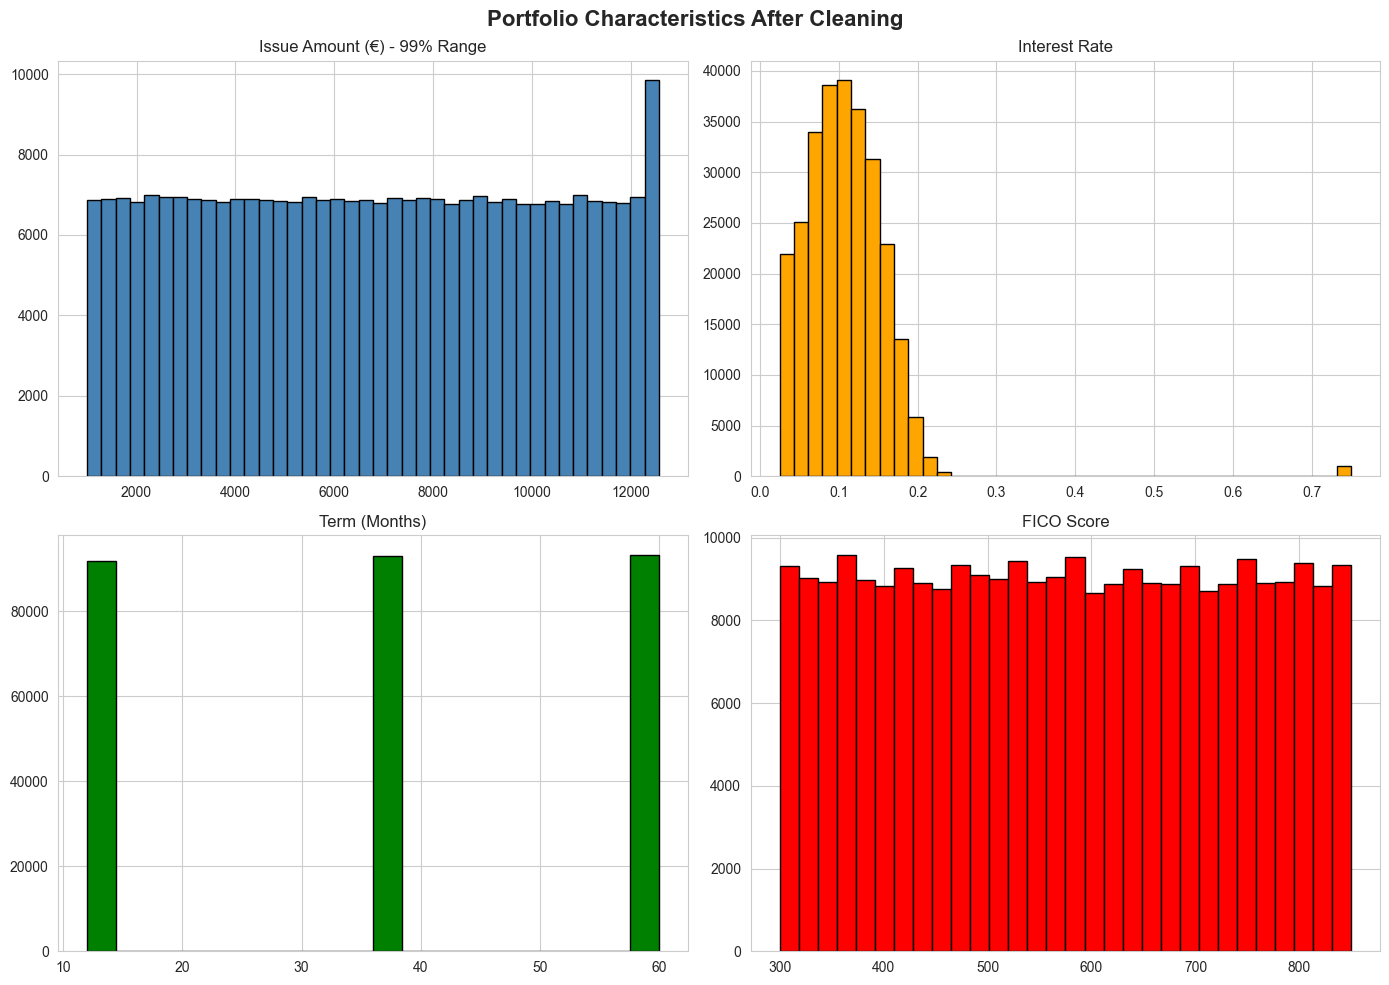

In [29]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10)
)

# Issue amount (99% range for visibility)
cutoff = df_clean["issue_amount"].quantile(0.99)

axes[0,0].hist(
    df_clean.loc[
        df_clean["issue_amount"] <= cutoff,
        "issue_amount"
    ],
    bins=40,
    color="steelblue",
    edgecolor="black"
)

axes[0,0].set_title("Issue Amount (€) - 99% Range")

# Interest rate
axes[0,1].hist(
    df_clean["interest_rate"].dropna(),
    bins=40,
    color="orange",
    edgecolor="black"
)

axes[0,1].set_title("Interest Rate")

# Term
axes[1,0].hist(
    df_clean["term"],
    bins=20,
    color="green",
    edgecolor="black"
)

axes[1,0].set_title("Term (Months)")

# FICO
axes[1,1].hist(
    df_clean["fico_score"].dropna(),
    bins=30,
    color="red",
    edgecolor="black"
)

axes[1,1].set_title("FICO Score")

plt.suptitle(
    "Portfolio Characteristics After Cleaning",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig01_portfolio_characteristics.pdf",
    dpi=300
)

plt.show()

### Figure 2

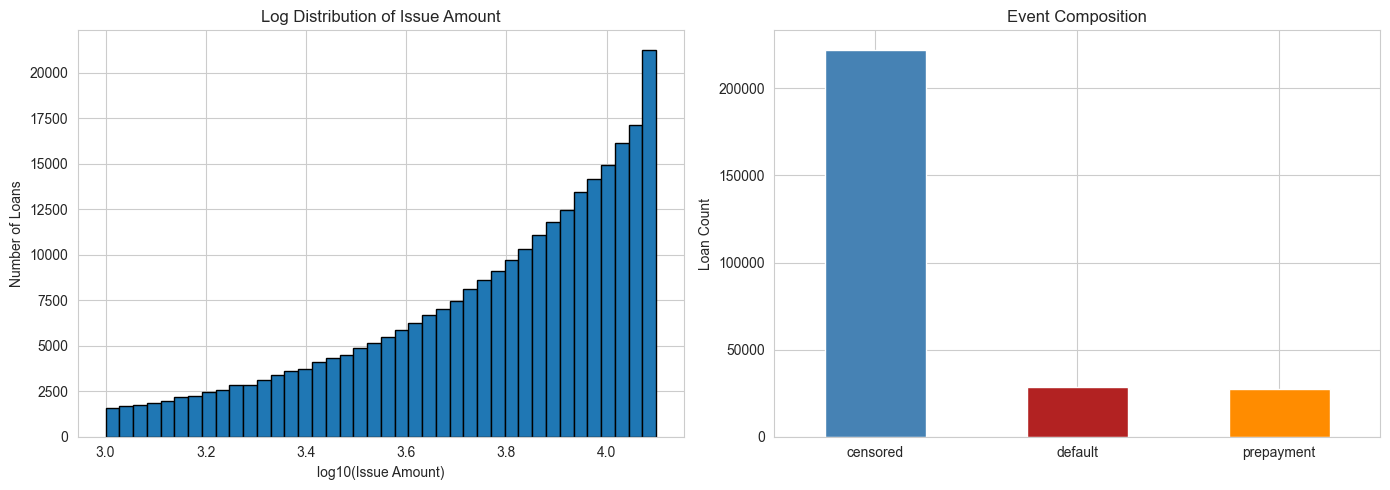

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -----------------------------
# Panel A: Log Issue Amount
# -----------------------------
axes[0].hist(
    np.log10(df_clean["issue_amount"]),
    bins=40,
    edgecolor="black"
)

axes[0].set_title("Log Distribution of Issue Amount")
axes[0].set_xlabel("log10(Issue Amount)")
axes[0].set_ylabel("Number of Loans")


# -----------------------------
# Panel B: Event Composition
# -----------------------------
event_summary["count"].plot(
    kind="bar",
    ax=axes[1],
    color=["steelblue", "firebrick", "darkorange"]
)

axes[1].set_title("Event Composition")
axes[1].set_xlabel("")
axes[1].set_ylabel("Loan Count")

# Optional: rotate x-axis labels
axes[1].tick_params(axis="x", rotation=0)


plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig02_issue_amount_event_composition.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Figure 3

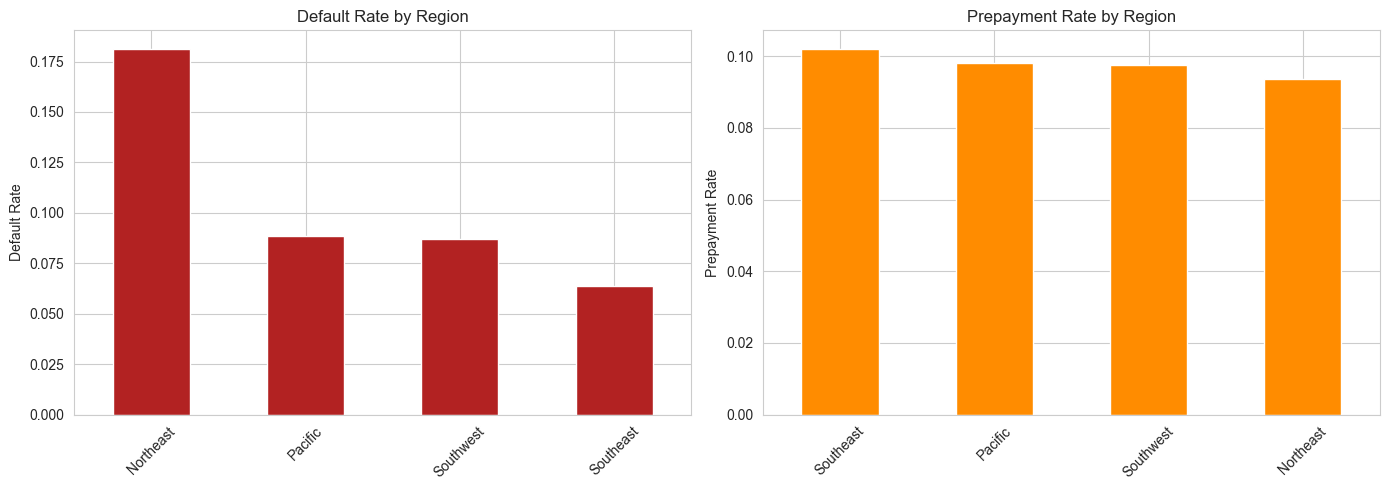

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -----------------------------
# Panel A: Default Rate
# -----------------------------
region_rates["default_rate"] \
    .sort_values(ascending=False) \
    .plot(
        kind="bar",
        ax=axes[0],
        color="firebrick"
    )

axes[0].set_title("Default Rate by Region")
axes[0].set_xlabel("")
axes[0].set_ylabel("Default Rate")
axes[0].tick_params(axis="x", rotation=45)


# -----------------------------
# Panel B: Prepayment Rate
# -----------------------------
region_rates["prepayment_rate"] \
    .sort_values(ascending=False) \
    .plot(
        kind="bar",
        ax=axes[1],
        color="darkorange"
    )

axes[1].set_title("Prepayment Rate by Region")
axes[1].set_xlabel("")
axes[1].set_ylabel("Prepayment Rate")
axes[1].tick_params(axis="x", rotation=45)


plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig03_region_default_prepayment_rates.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Figure 4

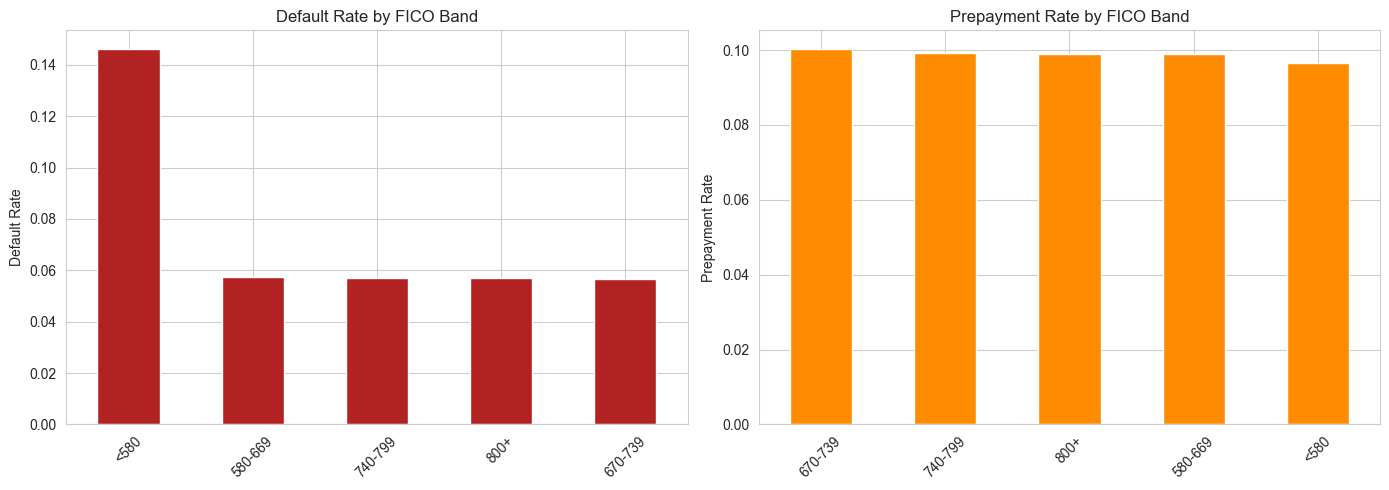

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -----------------------------
# Panel A: Default Rate
# -----------------------------
fico_rates["default_rate"] \
    .sort_values(ascending=False) \
    .plot(
        kind="bar",
        ax=axes[0],
        color="firebrick"
    )

axes[0].set_title("Default Rate by FICO Band")
axes[0].set_xlabel("")
axes[0].set_ylabel("Default Rate")
axes[0].tick_params(axis="x", rotation=45)


# -----------------------------
# Panel B: Prepayment Rate
# -----------------------------
fico_rates["prepayment_rate"] \
    .sort_values(ascending=False) \
    .plot(
        kind="bar",
        ax=axes[1],
        color="darkorange"
    )


axes[1].set_title("Prepayment Rate by FICO Band")
axes[1].set_xlabel("")
axes[1].set_ylabel("Prepayment Rate")
axes[1].tick_params(axis="x", rotation=45)


plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig04_FICO_default_prepayment_rates.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Figure 5

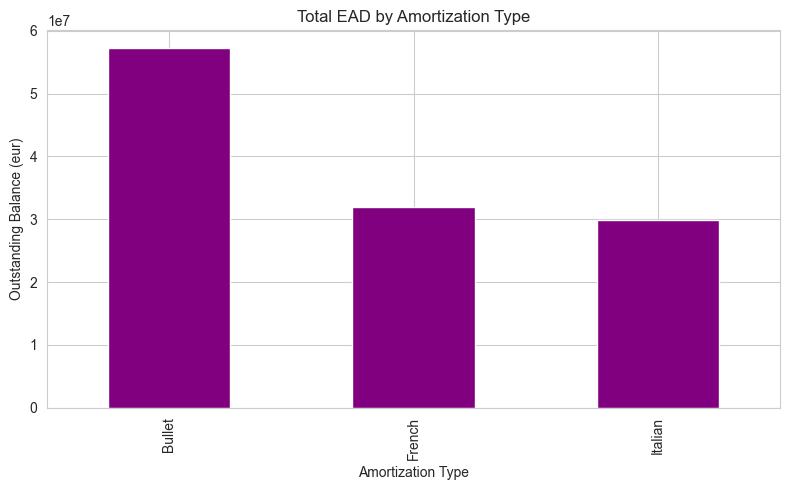

In [33]:
plt.figure(figsize=(8, 5))

ead_summary["total_balance_at_obs_end"] \
.sort_values(ascending=False) \
.plot(
    kind="bar",
    color="purple"
)

plt.title("Total EAD by Amortization Type")
plt.ylabel("Outstanding Balance (eur)")
plt.xlabel("Amortization Type")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig05_total_ead_by_amortization.pdf",
    dpi=300
)

plt.show()

### Figure 6

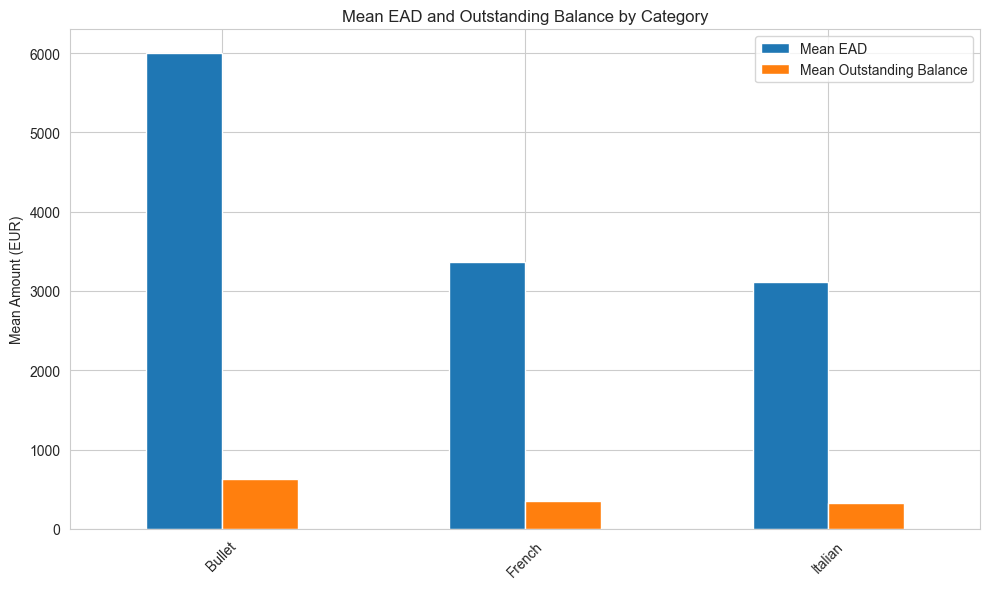

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

# Combine the two series
comparison = pd.DataFrame({
    "Mean EAD": default_ead_summary["mean_ead"],
    "Mean Outstanding Balance": ead_summary["mean_balance_at_obs_end"]
})

comparison.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Mean EAD and Outstanding Balance by Category")
ax.set_xlabel("")
ax.set_ylabel("Mean Amount (EUR)")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig06_mean_ead_vs_balance.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Figure 7

/var/folders/d4/lc69ql_15rn7y232fc6rn2nr0000gn/T/ipykernel_53210/258312224.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heat = pd.pivot_table(


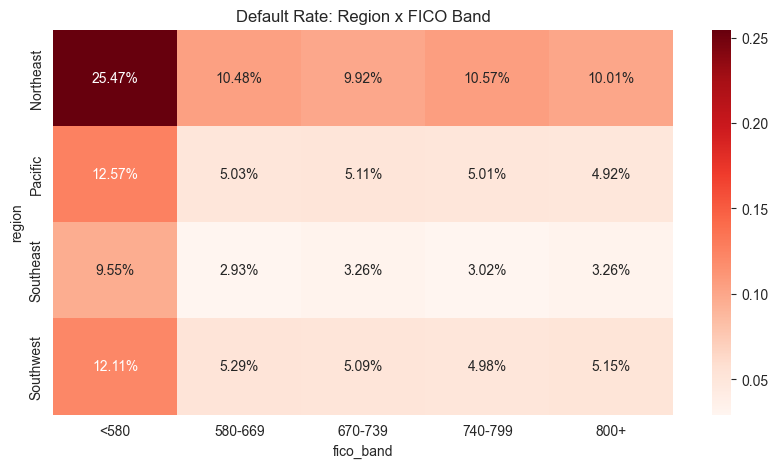

In [35]:
heat = pd.pivot_table(
    df_clean,
    index="region",
    columns="fico_band",
    values="default_event",
    aggfunc="mean"
)

plt.figure(figsize=(10,5))

sns.heatmap(
    heat,
    annot=True,
    fmt=".2%",
    cmap="Reds"
)

plt.title("Default Rate: Region x FICO Band")

plt.savefig(
    FIG_DIR / "fig07_region_fico_heatmap.pdf",
    dpi=300
)

plt.show()

# Extreme exposure investigation

median loan amount is only about 6,830, 75% of loans are below about 9,752, but the maximum is almost 50 million. This strongly suggests extreme outliers.

In [36]:
print("\n" + "=" * 80)
print("ISSUE AMOUNT EXTREME QUANTILES")
print("=" * 80)

display(
    df_clean["issue_amount"]
    .quantile([0.95, 0.99, 0.995, 0.999])
    .round(0)
    .astype(int)
    .to_frame("Issue Amount (eur)")
)
top_exposures = (
    df_clean
    .nlargest(20, "issue_amount")
)

display(top_exposures)


ISSUE AMOUNT EXTREME QUANTILES


,Issue Amount (eur)
0.950,12101
0.990,12560
0.995,12560
0.999,12560


,origination_date,loan_id,region,fico_score,term,maturity_date,default_date,prepayment_date,obs_end_date,issue_amount,...,event_date,event_type,censoring_date,analysis_end_date,loan_age_days,loan_age_months,EAD_at_default,balance_at_prepayment,balance_at_obs_end,fico_band
115,1994-02-01,ID_00001110,Northeast,765.0,60,1999-02-01,1997-06-01,NaT,2026-06-16,12560.0,...,1997-06-01,default,1999-02-01,1997-06-01,1216,39.950719,12560.000000,NaN,0.0,740-799
323,1996-03-01,ID_00003699,Northeast,681.0,60,2001-03-01,1997-02-01,NaT,2026-06-16,12560.0,...,1997-02-01,default,2001-03-01,1997-02-01,337,11.071869,10257.333333,NaN,0.0,670-739
464,1997-10-01,ID_00005583,Northeast,833.0,36,2000-10-01,NaT,1998-04-16,2026-06-16,12560.0,...,1998-04-16,prepayment,2000-10-01,1998-04-16,197,6.472279,NaN,10635.040687,0.0,800+
562,1998-10-01,ID_00006757,Northeast,631.0,36,2001-10-01,2000-12-01,NaT,2026-06-16,12560.0,...,2000-12-01,default,2001-10-01,2000-12-01,792,26.020534,3488.888889,NaN,0.0,580-669
716,1999-02-01,ID_00007128,Northeast,612.0,12,2000-02-01,NaT,NaT,2026-06-16,12560.0,...,NaT,censored,2000-02-01,2000-02-01,365,11.991786,NaN,NaN,NaN,580-669
727,1999-02-01,ID_00007139,Northeast,715.0,12,2000-02-01,NaT,NaT,2026-06-16,12560.0,...,NaT,censored,2000-02-01,2000-02-01,365,11.991786,NaN,NaN,0.0,670-739
741,1999-02-01,ID_00007153,Northeast,837.0,36,2002-02-01,NaT,NaT,2026-06-16,12560.0,...,NaT,censored,2002-02-01,2002-02-01,1096,36.008214,NaN,NaN,0.0,800+
1181,1999-06-01,ID_00007593,Northeast,648.0,60,2004-06-01,NaT,NaT,2026-06-16,12560.0,...,NaT,censored,2004-06-01,2004-06-01,1827,60.024641,NaN,NaN,0.0,580-669
1301,1999-08-01,ID_00007713,Northeast,835.0,36,2002-08-01,NaT,NaT,2026-06-16,12560.0,...,NaT,censored,2002-08-01,2002-08-01,1096,36.008214,NaN,NaN,0.0,800+
1692,1999-12-01,ID_00008104,Northeast,665.0,12,2000-12-01,NaT,NaT,2026-06-16,12560.0,...,NaT,censored,2000-12-01,2000-12-01,366,12.024641,NaN,NaN,0.0,580-669


NaT: Not a Time means no valid default date exists for a specific loan

In [37]:
print(
    f"95th percentile issue amount: "
    f"€{df_clean['issue_amount'].quantile(0.95):,.0f}"
)

print(
    f"99.9th percentile issue amount: "
    f"€{df_clean['issue_amount'].quantile(0.999):,.0f}"
)

95th percentile issue amount: €12,101
99.9th percentile issue amount: €12,560


# For the report:

Loan sizes are highly concentrated. While 95% of loans are smaller than approximately €12,100, the 99.9th percentile reaches approximately €46 million. This indicates the presence of extreme exposure concentrations that may dominate portfolio tail risk.

1. Structural Bias Discussion (REPORT)

You can copy this almost directly into your report.

Structural Data Quality and Survivorship Risks
Issue 1: Administrative Censoring

Approximately 80% of loans are censored and neither defaulted nor prepaid prior to the observation end date.

If censored loans were incorrectly treated as non-defaulting loans, default risk would be substantially underestimated because many loans simply have not yet experienced an observable termination event.

Potential bias:

Underestimates the true default probability and produces overly optimistic credit risk estimates.

Issue 2: Survivor Bias

The dataset contains only loans surviving long enough to enter the securitization pool.

Loans that defaulted very early may be underrepresented relative to the original origination population.

Potential bias:

Default risk may be underestimated because the observed portfolio may be healthier than the full historical lending population.

Issue 3: Regional Reporting Differences

The raw dataset contained multiple region spellings and coding inconsistencies.

Examples included:

- NORTHEAST

- Northe@st

- PACIFIC

- P@cific

Regional operational practices may also differ across servicing systems.

Potential bias:

Apparent differences in regional default rates may partly reflect data-recording differences rather than true economic risk.

Issue 4: Missing Interest Rates

A total of 5,886 loans retained missing interest rates after cleaning.

Because amortization schedules depend directly on the contractual interest rate, missing rates reduce confidence in EAD calculations.

Potential bias:

EAD and portfolio loss estimates may be understated or overstated for affected loans.

Issue 5: Extreme Loan Amounts

The portfolio contains a small number of exceptionally large exposures approaching €50 million, while the median loan size is only €6,830.

Potential bias:

Summary statistics based on averages may be dominated by a very small number of large loans and therefore misrepresent the typical borrower.

2. Risk Driver Hypotheses (REPORT)

Again, you can use this directly.

Preliminary Risk Driver Hypotheses

Exploratory analysis suggests several variables are likely to explain future default behaviour.

Hypothesis 1: FICO Score Drives Default Risk

Default rates increase substantially for low-credit-quality borrowers.

Observed default rates:

FICO Band	Default Rate<580	14.61%
580-669	5.76%
670-739	5.67%
740-799	5.72%
800+	5.69%

Borrowers with FICO scores below 580 default at approximately 2.5 times the rate of all higher-quality segments.

Expectation:

FICO score will emerge as the strongest predictor of default timing in subsequent survival models.

Hypothesis 2: Regional Effects Are Important

The Northeast region exhibits substantially higher realised defaults than all other regions.

Observed default rates:

Region	Default RateNortheast	18.14%
Pacific	8.84%
Southwest	8.68%
Southeast	6.38%

Expectation:

Dependence structures may contain regional clustering effects.

Hypothesis 3: Amortization Type Influences Loss Severity

Bullet loans retain principal for longer periods and therefore exhibit larger outstanding balances during most of the loan life.

Observed mean EAD at default:

Type	Mean EADBullet	€217,475
Italian	€148,034
French	€143,738

Expectation:

Bullet loans may contribute disproportionately to tail losses even if default frequencies are similar.

Hypothesis 4: Concentration Risk Exists

The portfolio contains several extremely large loans approaching €50 million.

Expectation:

Portfolio tail risk may be driven by a small number of very large exposures despite apparent diversification by loan count.

Hypothesis 5: Shared Systematic Factors Exist

The strong regional variation in defaults suggests that borrower outcomes may not be independent.

Expectation:

Multi-factor dependence models may outperform simple independence assumptions.

In [38]:
df_clean.filter(
    regex="balance|EAD",
    axis=1
).columns.tolist()

['EAD_at_default', 'balance_at_prepayment', 'balance_at_obs_end']